<a href="https://colab.research.google.com/github/doradosanti/myProjects/blob/main/SLR%2CMLR%2CDT%2CSVR%2CMLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Business and Data Understanding

---



###Main Objective

The main objective of this assignment is to predict quality of wines based on various chemical attributes such as acidity, sugar content, pH, alcohol level, and sulfur dioxide concentration. By developing a predictive model, the goal is to understand which factors most strongly influene wine quality and how adjustments to these factors could lead to better production outcomes.

###Who benefits?
This analysis could benefit winemakers, who can use these insights to optimize fermentation conditions, ingredient ratios, and aging processes to consistently produce higher-quality wines. Distributors can align quality indicators and consumer preferences to accurately anticipate customers demand and set profitable pricing. Additonally, it can also benefit quality inspectors to help identify potential quality issues early in produciton saving time and resources.

###Target Variable and Predictor Variable Definitions

Our target variable is wine quality score which is a numeric rating assigned on a scale of 0 to 10 in this dataset. The goal is to predict wine quality as a numeric value based on several chemical attributes. Each predictor variable represents a chemical property of the wine that can influence its taste and overall quality.


*   Fixed Acidity: Concentration of non-volatile acids. Contributes to the wine's aging potential. Winemaker's adjust this for desired flavor balance.
*   Volatile Acidity: Amount of acetic acid. High levels of this reduce wine quality.
*   Citric Acid: Adds a citrus falvor and enhances freshness. Affects the perceived acididty of the wine.
*   Residual Sugar: Remaining sugar after fermentation. Impacts sweetness.
*   Chlorides: Salt content in wine. High levels can lead to undesirable taste.
*   Free Sulfure Dioxide: Prevents microbial growth and oxidation. This is critical for preservation and shelf life management.
*   Total Sulfur Dioxide: Total SO2 content free and unbound.
*   Density: Related to sugar and alcohol content. Used as a quality control indicator during fermentation.
*   pH: Measure of acidity. Helps ensure chemical stability and optimal fermentation.
*   Sulphates: Enhances antioxidant properties and overall wine stability.
*   Alcohol: Percentage of ethanol. Strongly correlated with aroma and quality.

###How can improving or changing these factors impact product quality?

A predictive model can help make better data-driven decisions such as improving production processes and refining ingredient sourcing for wines predicted to have higher quality scores.


###Success criteria
The success of the predictive model will be determined by how accurately it classifies wine quality scores and identify specific attributes that impact wine quality.

###Descriptive Analytics

---



In [ ]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import libraries
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans
from collections import Counter
from sklearn import preprocessing
from matplotlib import pyplot as plt
import numpy as np
from sklearn.svm import SVC #SVC for classification
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# Read data
winequality = pd.read_csv("/content/drive/MyDrive/IS470_data/winequality-red.csv")
winequality

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [ ]:
# Examine variable type
winequality.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [ ]:
#missing variables?
winequality.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Text(0.5, 1.0, 'Countplot of wine quality in data set')

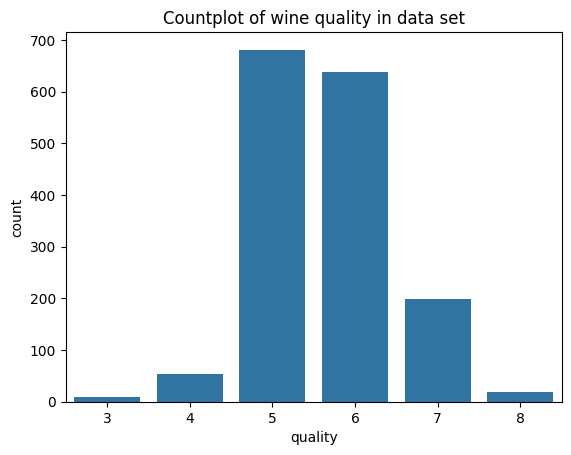

In [ ]:
# Countplot of wine quality
snsplot = sns.countplot(x='quality', data = winequality)
snsplot.set_title("Countplot of wine quality in data set")

In [ ]:
# exploring relationships among all numeric variables: correlation matrix
winequality[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol','quality']].corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397



*   Fixed acidity & Citric acid are +0.67 correlated. Wines with higher fixed acidity tend to have higher citric acid.
*   Fixed acidity & Density are +0.67 correlated as denser wines usually tend to have higher acid content.
*   Free sulfur dioxide & Total Sulfur Dioxide are +0.67 correlated. These two are strongly related because total SO2 includes free SO2.
*   pH & Fixed acidity are inversely related (-0.67). Higher acididty usually means lower pH.
*   Alcohol has strongest positive correlation (+0.476) with quality unlike volatile acidity that shows a strong negative correlation (-0.391) with quality. This suggests that wines with higher alcohol content tend to receive higher quality ratings and wines with higher volatile acidity tend to be rated lower.


Since none of these variables are correlated greater than 0.90 I believe all variables have value so I will keep all variables in the models.



In [ ]:
# Show the statistics of a numeric variable
winequality['quality'].describe()

,quality
count,1599.000000
mean,5.636023
std,0.807569
min,3.000000
25%,5.000000
50%,6.000000
75%,6.000000
max,8.000000


Text(0.5, 1.0, 'Histogram of Density')

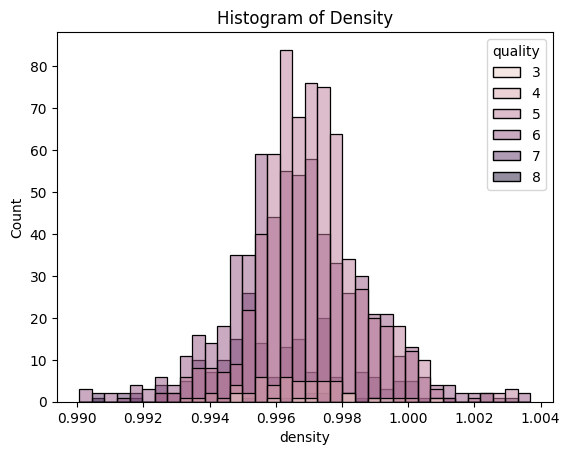

In [ ]:
# Histogram of a numeric variable by quality
snsplot = sns.histplot(x='density', hue='quality', data = winequality)
snsplot.set_title("Histogram of Density")

Text(0.5, 1.0, 'Histogram of pH in wine quality dataset')

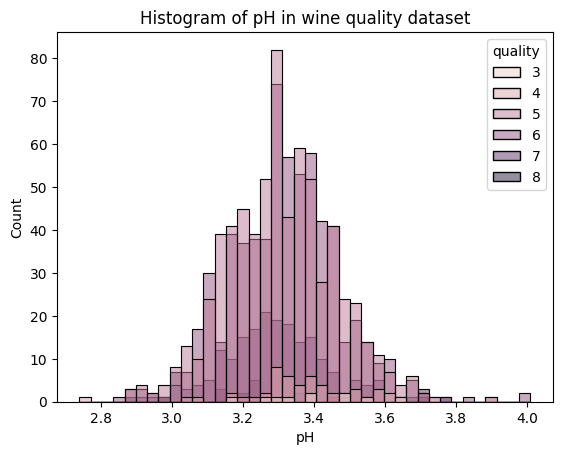

In [ ]:
# Histogram of a numeric variable by target variable
snsplot = sns.histplot(x='pH', hue='quality', data = winequality)
snsplot.set_title("Histogram of pH in wine quality dataset")

Text(0.5, 1.0, 'Histogram of alcohol in the dataset')

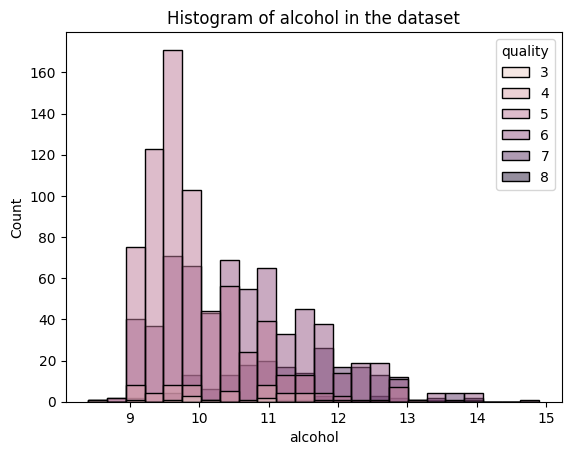

In [ ]:
# Histogram of a numeric variable by target variable
snsplot = sns.histplot(x='alcohol',hue='quality', data = winequality)
snsplot.set_title("Histogram of alcohol in the dataset")

In [ ]:
# Create dummy variables
winequality = pd.get_dummies(winequality, drop_first=True, dtype = int)
winequality

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [ ]:
# Partition the data
target = winequality['quality']
predictors = winequality.drop(['quality'],axis=1)
predictors_train, predictors_test, target_train, target_test = train_test_split(predictors, target, test_size=0.3, random_state=0)
print(predictors_train.shape, predictors_test.shape, target_train.shape, target_test.shape)

(1119, 11) (480, 11) (1119,) (480,)


Text(0.5, 1.0, 'Histogram of target variables in the training data set')

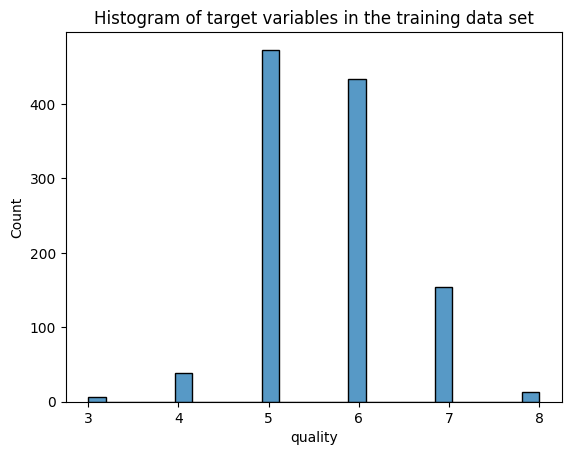

In [ ]:
# Examine the distribution of target variable for training data set
snsplot = sns.histplot(data = target_train)
snsplot.set_title("Histogram of target variables in the training data set")

Text(0.5, 1.0, 'Histogram of target variable in the testing data set')

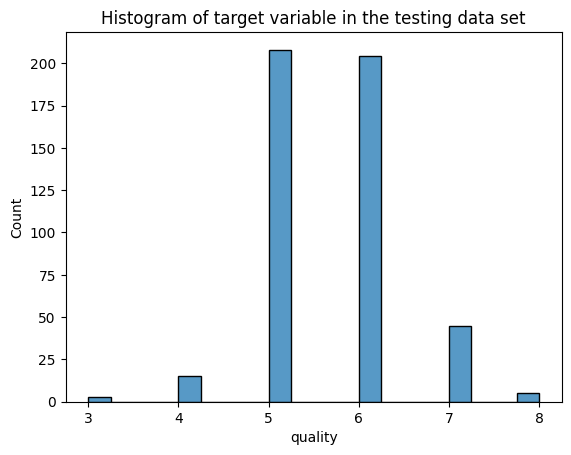

In [ ]:
# Examine the distribution of target variable for testing data set
snsplot = sns.histplot(data = target_test)
snsplot.set_title("Histogram of target variable in the testing data set")

#Simple Linear Regression

---



In [ ]:
# Build a simple linear regression model with only alcohol as predictor
model1 = linear_model.LinearRegression()
model1.fit(predictors_train[['alcohol']], target_train)

LinearRegression()

In [ ]:
# Show model summary
import statsmodels.api as sm
X2 = sm.add_constant(predictors_train[['alcohol']])
y = target_train
est = sm.OLS(y, X2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.213
Method:                 Least Squares   F-statistic:                     303.8
Date:                Wed, 19 Nov 2025   Prob (F-statistic):           2.29e-60
Time:                        08:04:28   Log-Likelihood:                -1235.3
No. Observations:                1119   AIC:                             2475.
Df Residuals:                    1117   BIC:                             2485.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9289      0.215      8.985      0.0

Alcohol explains 21% (r-squared = 0.214) of the variation in quality. Meaning other chemicals have value in quality (79% unexplained). Higher alcohol content = higher quality rating as shown by coefficient for every 1% of alcohol it raises quality score by 0.3576 points

In [ ]:
res = est2.resid
print(res.describe(percentiles=[0.25,0.5,0.75])[['min','25%', '50%','75%','max']])

min   -2.862486
25%   -0.398881
50%   -0.183051
75%    0.566631
max    2.495112
dtype: float64


In [ ]:
# Make predictions on testing data
prediction_on_test = model1.predict(predictors_test[['alcohol']])

In [ ]:
# Examine the evaluation results on testing data: MAE and RMSE
MAE = mean_absolute_error(target_test, prediction_on_test)
MSE = mean_squared_error(target_test, prediction_on_test)
RMSE = MSE ** 0.5 #ornp.sqrt(MSE)
print("MAE:", MAE)
print("RMSE:", RMSE)

MAE: 0.5230974814995663
RMSE: 0.6623121357628291


#Multiple Linear Regression

---



In [ ]:
# Build a multiple linear regression model with all predictors
model2 = linear_model.LinearRegression()
model2.fit(predictors_train, target_train)

LinearRegression()

In [ ]:
# Show model summary
import statsmodels.api as sm
X2 = sm.add_constant(predictors_train)
y = target_train
est = sm.OLS(y, X2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.371
Model:                            OLS   Adj. R-squared:                  0.365
Method:                 Least Squares   F-statistic:                     59.35
Date:                Wed, 19 Nov 2025   Prob (F-statistic):          1.86e-103
Time:                        08:04:28   Log-Likelihood:                -1110.6
No. Observations:                1119   AIC:                             2245.
Df Residuals:                    1107   BIC:                             2305.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   21.0111 

About 37% (r-squared = 0.371) of the variation in wine quality is explained by all the chemical predictors combined. As shown in the model alcohol still is a strong positive predictor (+0.2675, p <0.001) as well as sulphates (+0.8542, p<0.001) which positively affects wine quality, which makes sense because sulphates help preserve and enhance flavor. Volatile acidity (-1.2139), chlorides (-1.8976), and total sulfur dioxide(-0.0030), however, lower the quality.

In [ ]:
res = - est2.resid
print(res.describe(percentiles=[0.25,0.5,0.75])[['min','25%', '50%','75%','max']])

min   -1.795974
25%   -0.446311
50%    0.039130
75%    0.390185
max    2.669533
dtype: float64


In [ ]:
# Make predictions on testing data
prediction_on_test = model2.predict(predictors_test)

In [ ]:
# Examine the evaluation results on testing data: MAE and RMSE
MAE = mean_absolute_error(target_test, prediction_on_test)
#RMSE = mean_squared_error(target_test, prediction_on_test, squared=False)
MSE = mean_squared_error(target_test, prediction_on_test)
RMSE = MSE ** 0.5 #or np.sqrt(MSE)
print("MAE:", MAE)
print("RMSE:", RMSE)

MAE: 0.48712621645927945
RMSE: 0.6330721652189464


MAE and RMSE are slightly lower than in the single regression meaning multiple linear regression predicts more accurately and explains more variance than the simple model.

#Regression Trees

---



In [ ]:
# Build a regression tree model with max_depth=3
model3 = DecisionTreeRegressor(random_state=0, max_depth=3)
model3.fit(predictors_train, target_train)

DecisionTreeRegressor(max_depth=3, random_state=0)

[Text(0.5, 0.875, 'alcohol <= 10.525\nsquared_error = 0.677\nsamples = 1119\nvalue = 5.651'),
 Text(0.25, 0.625, 'sulphates <= 0.555\nsquared_error = 0.434\nsamples = 690\nvalue = 5.384'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'chlorides <= 0.169\nsquared_error = 0.281\nsamples = 230\nvalue = 5.122'),
 Text(0.0625, 0.125, 'squared_error = 0.258\nsamples = 228\nvalue = 5.136'),
 Text(0.1875, 0.125, 'squared_error = 0.25\nsamples = 2\nvalue = 3.5'),
 Text(0.375, 0.375, 'total sulfur dioxide <= 46.5\nsquared_error = 0.458\nsamples = 460\nvalue = 5.515'),
 Text(0.3125, 0.125, 'squared_error = 0.466\nsamples = 246\nvalue = 5.691'),
 Text(0.4375, 0.125, 'squared_error = 0.374\nsamples = 214\nvalue = 5.313'),
 Text(0.75, 0.625, 'sulphates <= 0.615\nsquared_error = 0.77\nsamples = 429\nvalue = 6.082'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'volatile acidity <= 1.0\nsquared_error = 0.747\nsamples = 160\nvalue = 5.625'),
 Text(0.5625, 0.125, 'squared_error = 0.569\nsampl

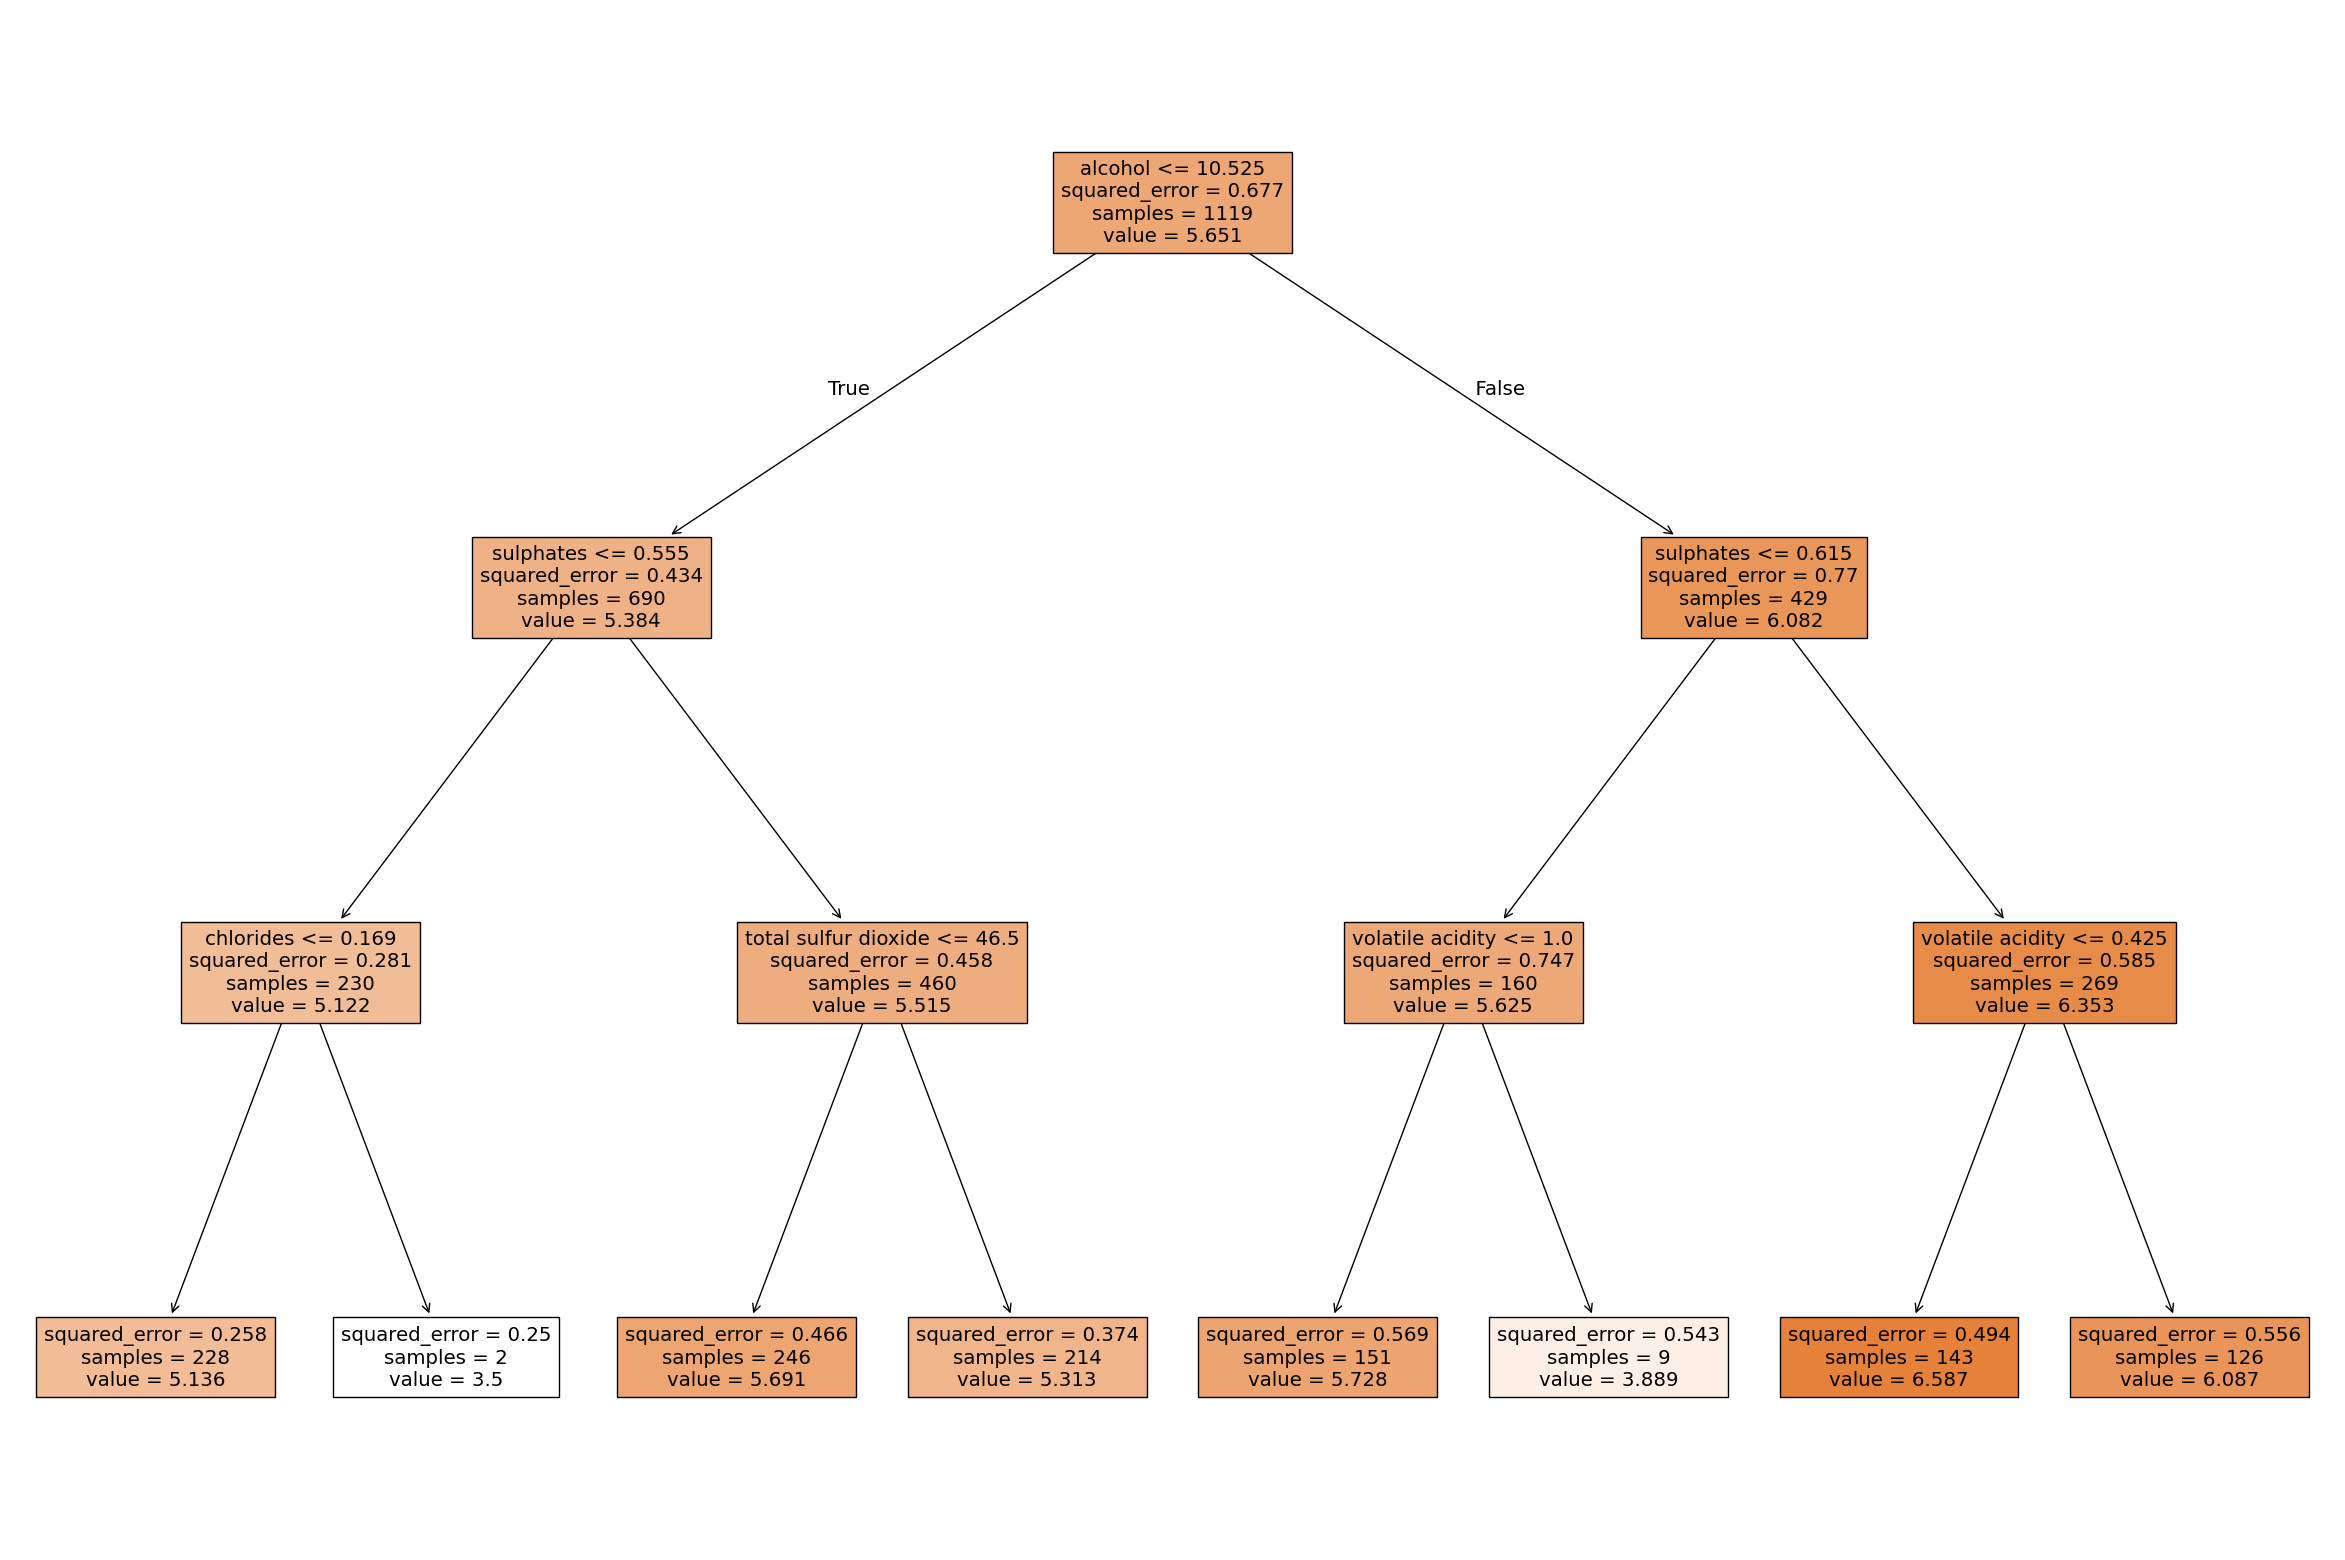

In [ ]:
from matplotlib import pyplot as plt
from sklearn import tree
fig = plt.figure(figsize=(30,20))
tree.plot_tree(model3,
               feature_names=list(predictors_train.columns),
               filled=True)

In [ ]:
# Make predictions on testing data
prediction_on_test = model3.predict(predictors_test)

In [ ]:
# Examine the evaluation results on testing data: MAE and RMSE
MAE = mean_absolute_error(target_test, prediction_on_test)
#RMSE = mean_squared_error(target_test, prediction_on_test, squared=False)
MSE = mean_squared_error(target_test, prediction_on_test)
RMSE = MSE ** 0.5 #or np.sqrt(MSE)
print("MAE:", MAE)
print("RMSE:", RMSE)

MAE: 0.5453637284748408
RMSE: 0.6980934560458724


####Performance Summary
As predicted alcohol and sulphates are dominant predictors. As the model shows wines with higher alcohol and high sulphates score best. At the root is shows alcohol at an average wine quality of 5.65 before the split. Then in the left branch it shows lower sulphates (split: sulphates <= 0.555) and low alcohol produce lower score of 5.1-5.3. Higher sulphates showed slightly better score (5.5-5.7) in the left branch too. Right branch (split: sulphates <= 0.615) high alcohol and high sulphates produce the highest predicted quality (6.6). Wines with low sulphates or high volatile acidity rate lower (5.6) in the right branch. As for MAE and RMSE are higher than previous regression models. Overall, the regression tree is slightly less acurate than previous models but more interpretable.

#Support Vector Regression (SVR)

---



In [ ]:
# Build a SVM model with default setting (C = 1.0)
model_SVM1 = SVR()
model_SVM1.fit(predictors_train, target_train)

SVR()

In [ ]:
# Make predictions on testing data
prediction_on_test = model_SVM1.predict(predictors_test)

In [ ]:
# Examine the evaluation results on testing data: MAE and RMSE
MAE = mean_absolute_error(target_test, prediction_on_test)
MSE = mean_squared_error(target_test, prediction_on_test)
#RMSE = mean_squared_error(target_test, prediction_on_test, squared=False)
RMSE = MSE**0.5
print("MAE:", MAE)
print("RMSE:", RMSE)

MAE: 0.5372875742404191
RMSE: 0.7131247064180449


In [ ]:
# Build a SVM model C= 10
model_SVM2 = SVR(C = 10.0)
model_SVM2.fit(predictors_train, target_train)

SVR(C=10.0)

In [ ]:
# Make predictions on testing data
prediction_on_test = model_SVM2.predict(predictors_test)

In [ ]:
# Examine the evaluation results on testing data: MAE and RMSE
MAE = mean_absolute_error(target_test, prediction_on_test)
MSE = mean_squared_error(target_test, prediction_on_test)
#RMSE = mean_squared_error(target_test, prediction_on_test, squared=False)
RMSE = MSE**0.5
print("MAE:", MAE)
print("RMSE:", RMSE)

MAE: 0.4940382849958881
RMSE: 0.6467564770982447


In [ ]:
# Build a SVM model C= 100
model_SVM3 = SVR(C = 100.0)
model_SVM3.fit(predictors_train, target_train)

SVR(C=100.0)

In [ ]:
# Make predictions on testing data
prediction_on_test = model_SVM3.predict(predictors_test)

In [ ]:
# Examine the evaluation results on testing data: MAE and RMSE
MAE = mean_absolute_error(target_test, prediction_on_test)
MSE = mean_squared_error(target_test, prediction_on_test)
#RMSE = mean_squared_error(target_test, prediction_on_test, squared=False)
RMSE = MSE**0.5
print("MAE:", MAE)
print("RMSE:", RMSE)

MAE: 0.4804593094240977
RMSE: 0.6260026845036791


####Summary of performance
C = 1.0 shows slight underfitting and while C=100 shows better performance a high C has risk of generalizing and overfitting. C = 10 might generalize better and has better balance between accuracy (MAE: 0.49 and RSME: 0.65).

#Multi-layer Perceptron

---



In [ ]:
#Build MLP model
model_MLP = MLPRegressor(hidden_layer_sizes=(16,8), random_state=1)
model_MLP.fit(predictors_train, target_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(16, 8), random_state=1)

In [ ]:
# Make predictions on testing data
prediction_on_test = model_MLP.predict(predictors_test)

In [ ]:
# Examine the evaluation results on testing data: MAE and RMSE
MAE = mean_absolute_error(target_test, prediction_on_test)
MSE = mean_squared_error(target_test, prediction_on_test)
#RMSE = mean_squared_error(target_test, prediction_on_test, squared=False)
RMSE = MSE**0.5
print("MAE:", MAE)
print("RMSE:", RMSE)

MAE: 0.5723368999426094
RMSE: 0.7342746057910711


This network is small. MAE and RMSE are higher than other models (SVR and Multiple linear regression). The model is overall underfitting.

In [ ]:
# Build MLP model
model_MLP2 = MLPRegressor(hidden_layer_sizes=(64,32,4), random_state=1)
model_MLP2.fit(predictors_train, target_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(64, 32, 4), random_state=1)

In [ ]:
# Make predictions on testing data
prediction_on_test = model_MLP2.predict(predictors_test)

In [ ]:
# Examine the evaluation results on testing data: MAE and RMSE
MAE = mean_absolute_error(target_test, prediction_on_test)
MSE = mean_squared_error(target_test, prediction_on_test)
#RMSE = mean_squared_error(target_test, prediction_on_test, squared=False)
RMSE = MSE**0.5
print("MAE:", MAE)
print("RMSE:", RMSE)

MAE: 0.5000921524762943
RMSE: 0.6471270650554262


MAE and RMSE are similar to SVR (C=10) model. 3 layers has much more complexity and the smaller MLP lacks capacity to capture relationships.

#Model Comparison

---



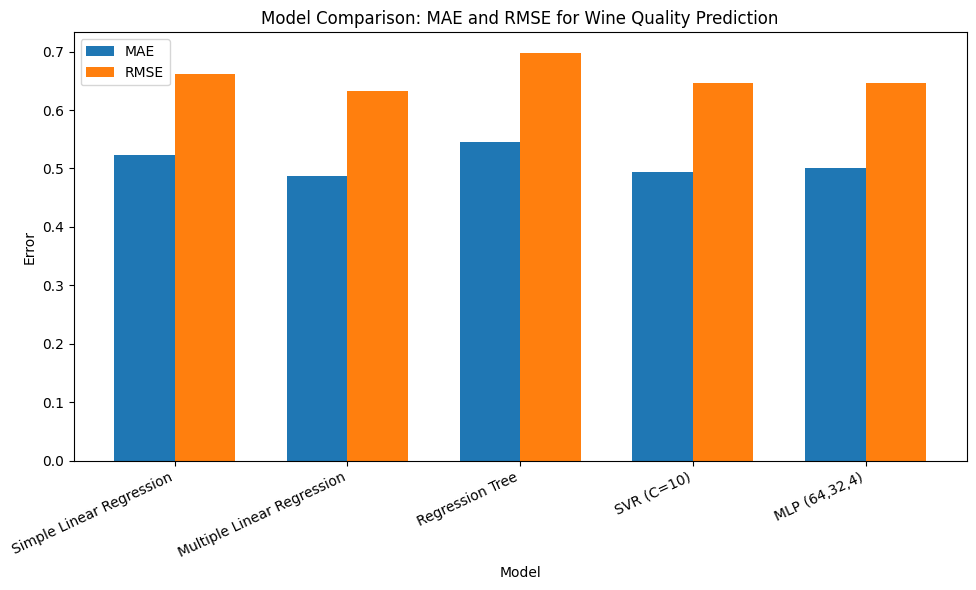

In [ ]:
# Data summary
data = {
    'Model': [
        'Simple Linear Regression',
        'Multiple Linear Regression',
        'Regression Tree',
        'SVR (C=10)',
        'MLP (64,32,4)'
    ],
    'MAE': [0.523, 0.487, 0.545, 0.494, 0.500],
    'RMSE': [0.662, 0.633, 0.698, 0.647, 0.647]
}

df = pd.DataFrame(data)

# Plot side-by-side bars
x = np.arange(len(df['Model']))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
bar1 = ax.bar(x - width/2, df['MAE'], width, label='MAE')
bar2 = ax.bar(x + width/2, df['RMSE'], width, label='RMSE')

ax.set_xlabel('Model')
ax.set_ylabel('Error')
ax.set_title('Model Comparison: MAE and RMSE for Wine Quality Prediction')
ax.set_xticks(x)
ax.set_xticklabels(df['Model'], rotation=25, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Create a dictionary of results
results = {
    'Model': [
        'Simple Linear Regression',
        'Multiple Linear Regression',
        'Regression Tree (max_depth=3)',
        'SVR (C=10)',
        'MLP (64, 32, 4)'
    ],
    'MAE': [0.523, 0.487, 0.545, 0.494, 0.500],
    'RMSE': [0.662, 0.633, 0.698, 0.647, 0.647]
}

# Convert dictionary to DataFrame
comparison_table = pd.DataFrame(results)

# Sort by RMSE (optional, to show best model first)
comparison_table = comparison_table.sort_values(by='RMSE', ascending=True).reset_index(drop=True)

# Display the table
print(comparison_table)

                           Model    MAE   RMSE
0     Multiple Linear Regression  0.487  0.633
1                     SVR (C=10)  0.494  0.647
2                MLP (64, 32, 4)  0.500  0.647
3       Simple Linear Regression  0.523  0.662
4  Regression Tree (max_depth=3)  0.545  0.698


As shown through the bar chart the multiple linear regression model achieved the lowest MAE (0.487) and RMSE (0.633) indicating it provides the most accurate predictions of wine quality. The regression tree model was the least accurate (RMSE = 0.7) but provides easy interpretability. Both the SVM and MLP models show similar results higher errors than Multiple linear regression model. This suggests that the relationship between the chemical attributes and wine quality is linear. Overall, the multiple linear regression model is the best model for predicting wine quality because it achieves the best trade off between accuracy, simplicity, and interpretability.

#Classfication

---



###Using SVC for prediction
To use SVC model effectively for this dataset I used a binary classification approach.


*   Good quality score >5 = 1(True)
*   Otherwise bad quality score =0 (False)




In [ ]:
winequality['quality_binary'] = winequality['quality'].apply(
    lambda x: 1 if x > 5 else 0
)

In [ ]:
# Check the class distribution
print("Class distribution (0 = bad, 1 = good):")
print(winequality['quality_binary'].value_counts(normalize=True))

Class distribution (0 = bad, 1 = good):
quality_binary
1    0.534709
0    0.465291
Name: proportion, dtype: float64


In [ ]:
# Drop the target variable and put all the predictors in a new dataframe
predictors = winequality.drop(['quality', 'quality_binary'],axis=1)
target = winequality['quality_binary']

In [ ]:
# Apply minmax normalization on predictors
scaler = MinMaxScaler()
predictors_normalized = pd.DataFrame(
    scaler.fit_transform(predictors),
    columns=predictors.columns
)

In [ ]:
# Partition the data
predictors_train, predictors_test, target_train, target_test = train_test_split(predictors_normalized, target, test_size=0.3, random_state=0, stratify=target)
print(predictors_train.shape, predictors_test.shape, target_train.shape, target_test.shape)

(1119, 11) (480, 11) (1119,) (480,)


In [ ]:
# Build a SVM model with default setting
model_SVC = SVC(C = 10.0, kernel='rbf', class_weight='balanced', random_state=0)
model_SVC.fit(predictors_train, target_train)

SVC(C=10.0, class_weight='balanced', random_state=0)

In [ ]:
# Make predictions on testing data
prediction_on_test = model_SVC.predict(predictors_test)

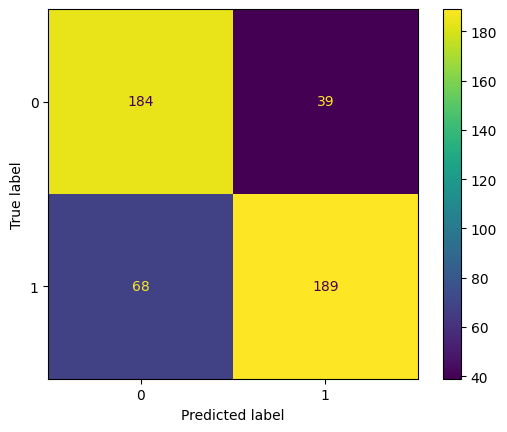

In [ ]:
# Examine the evaluation results on testing data: confusion_matrix
cm = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_SVC.classes_).plot()

In [ ]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

           0       0.73      0.83      0.77       223
           1       0.83      0.74      0.78       257

    accuracy                           0.78       480
   macro avg       0.78      0.78      0.78       480
weighted avg       0.78      0.78      0.78       480



The SVC model achieved an overall accuracy of 78% when classifying wines into categories. Precision for good wines (0.83) was higher than bad wines (0.73) meaning that the model predicted more good quality wines. Recall shows that 83% of bad wines and 74% of good wines were correctly identified.

###Using MLP Classifier

In [ ]:
#Build MLP model
model_MLPC = MLPClassifier(hidden_layer_sizes=(64,16,8), random_state=1)
model_MLPC.fit(predictors_train, target_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(64, 16, 8), random_state=1)

In [ ]:
# Make predictions on testing data
prediction_on_test = model_MLPC.predict(predictors_test)

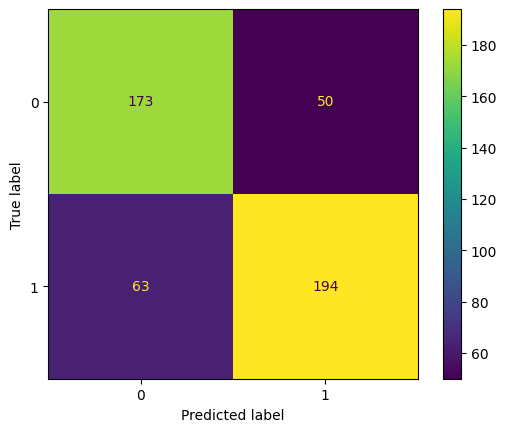

In [ ]:
# Examine the evaluation results on testing data: confusion_matrix
cm = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_MLPC.classes_).plot()

In [ ]:
# Examine the evaluation results on testing data
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

           0       0.73      0.78      0.75       223
           1       0.80      0.75      0.77       257

    accuracy                           0.76       480
   macro avg       0.76      0.77      0.76       480
weighted avg       0.77      0.76      0.76       480



Looking at precision scores it is slightly more reliable in identifying good wines (80% vs 73%). As for recall it performs fairly evenly across both categories when the model detects actual bad and good wines.

###Using Decision Tree

In [ ]:
# Build a decision tree model on training data with max_depth = 2
model_tree = DecisionTreeClassifier(criterion = "entropy",random_state = 1, max_depth = 2)
model_tree.fit(predictors_train, target_train)

DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=1)

[Text(0.5, 0.8333333333333334, 'alcohol <= 0.327\nentropy = 0.997\nsamples = 1119\nvalue = [521.0, 598.0]\nclass = Good (1)'),
 Text(0.25, 0.5, 'sulphates <= 0.147\nentropy = 0.957\nsamples = 700\nvalue = [435, 265]\nclass = Bad (0)'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'entropy = 0.755\nsamples = 276\nvalue = [216, 60]\nclass = Bad (0)'),
 Text(0.375, 0.16666666666666666, 'entropy = 0.999\nsamples = 424\nvalue = [219, 205]\nclass = Bad (0)'),
 Text(0.75, 0.5, 'sulphates <= 0.183\nentropy = 0.732\nsamples = 419\nvalue = [86, 333]\nclass = Good (1)'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'entropy = 0.931\nsamples = 179\nvalue = [62.0, 117.0]\nclass = Good (1)'),
 Text(0.875, 0.16666666666666666, 'entropy = 0.469\nsamples = 240\nvalue = [24, 216]\nclass = Good (1)')]

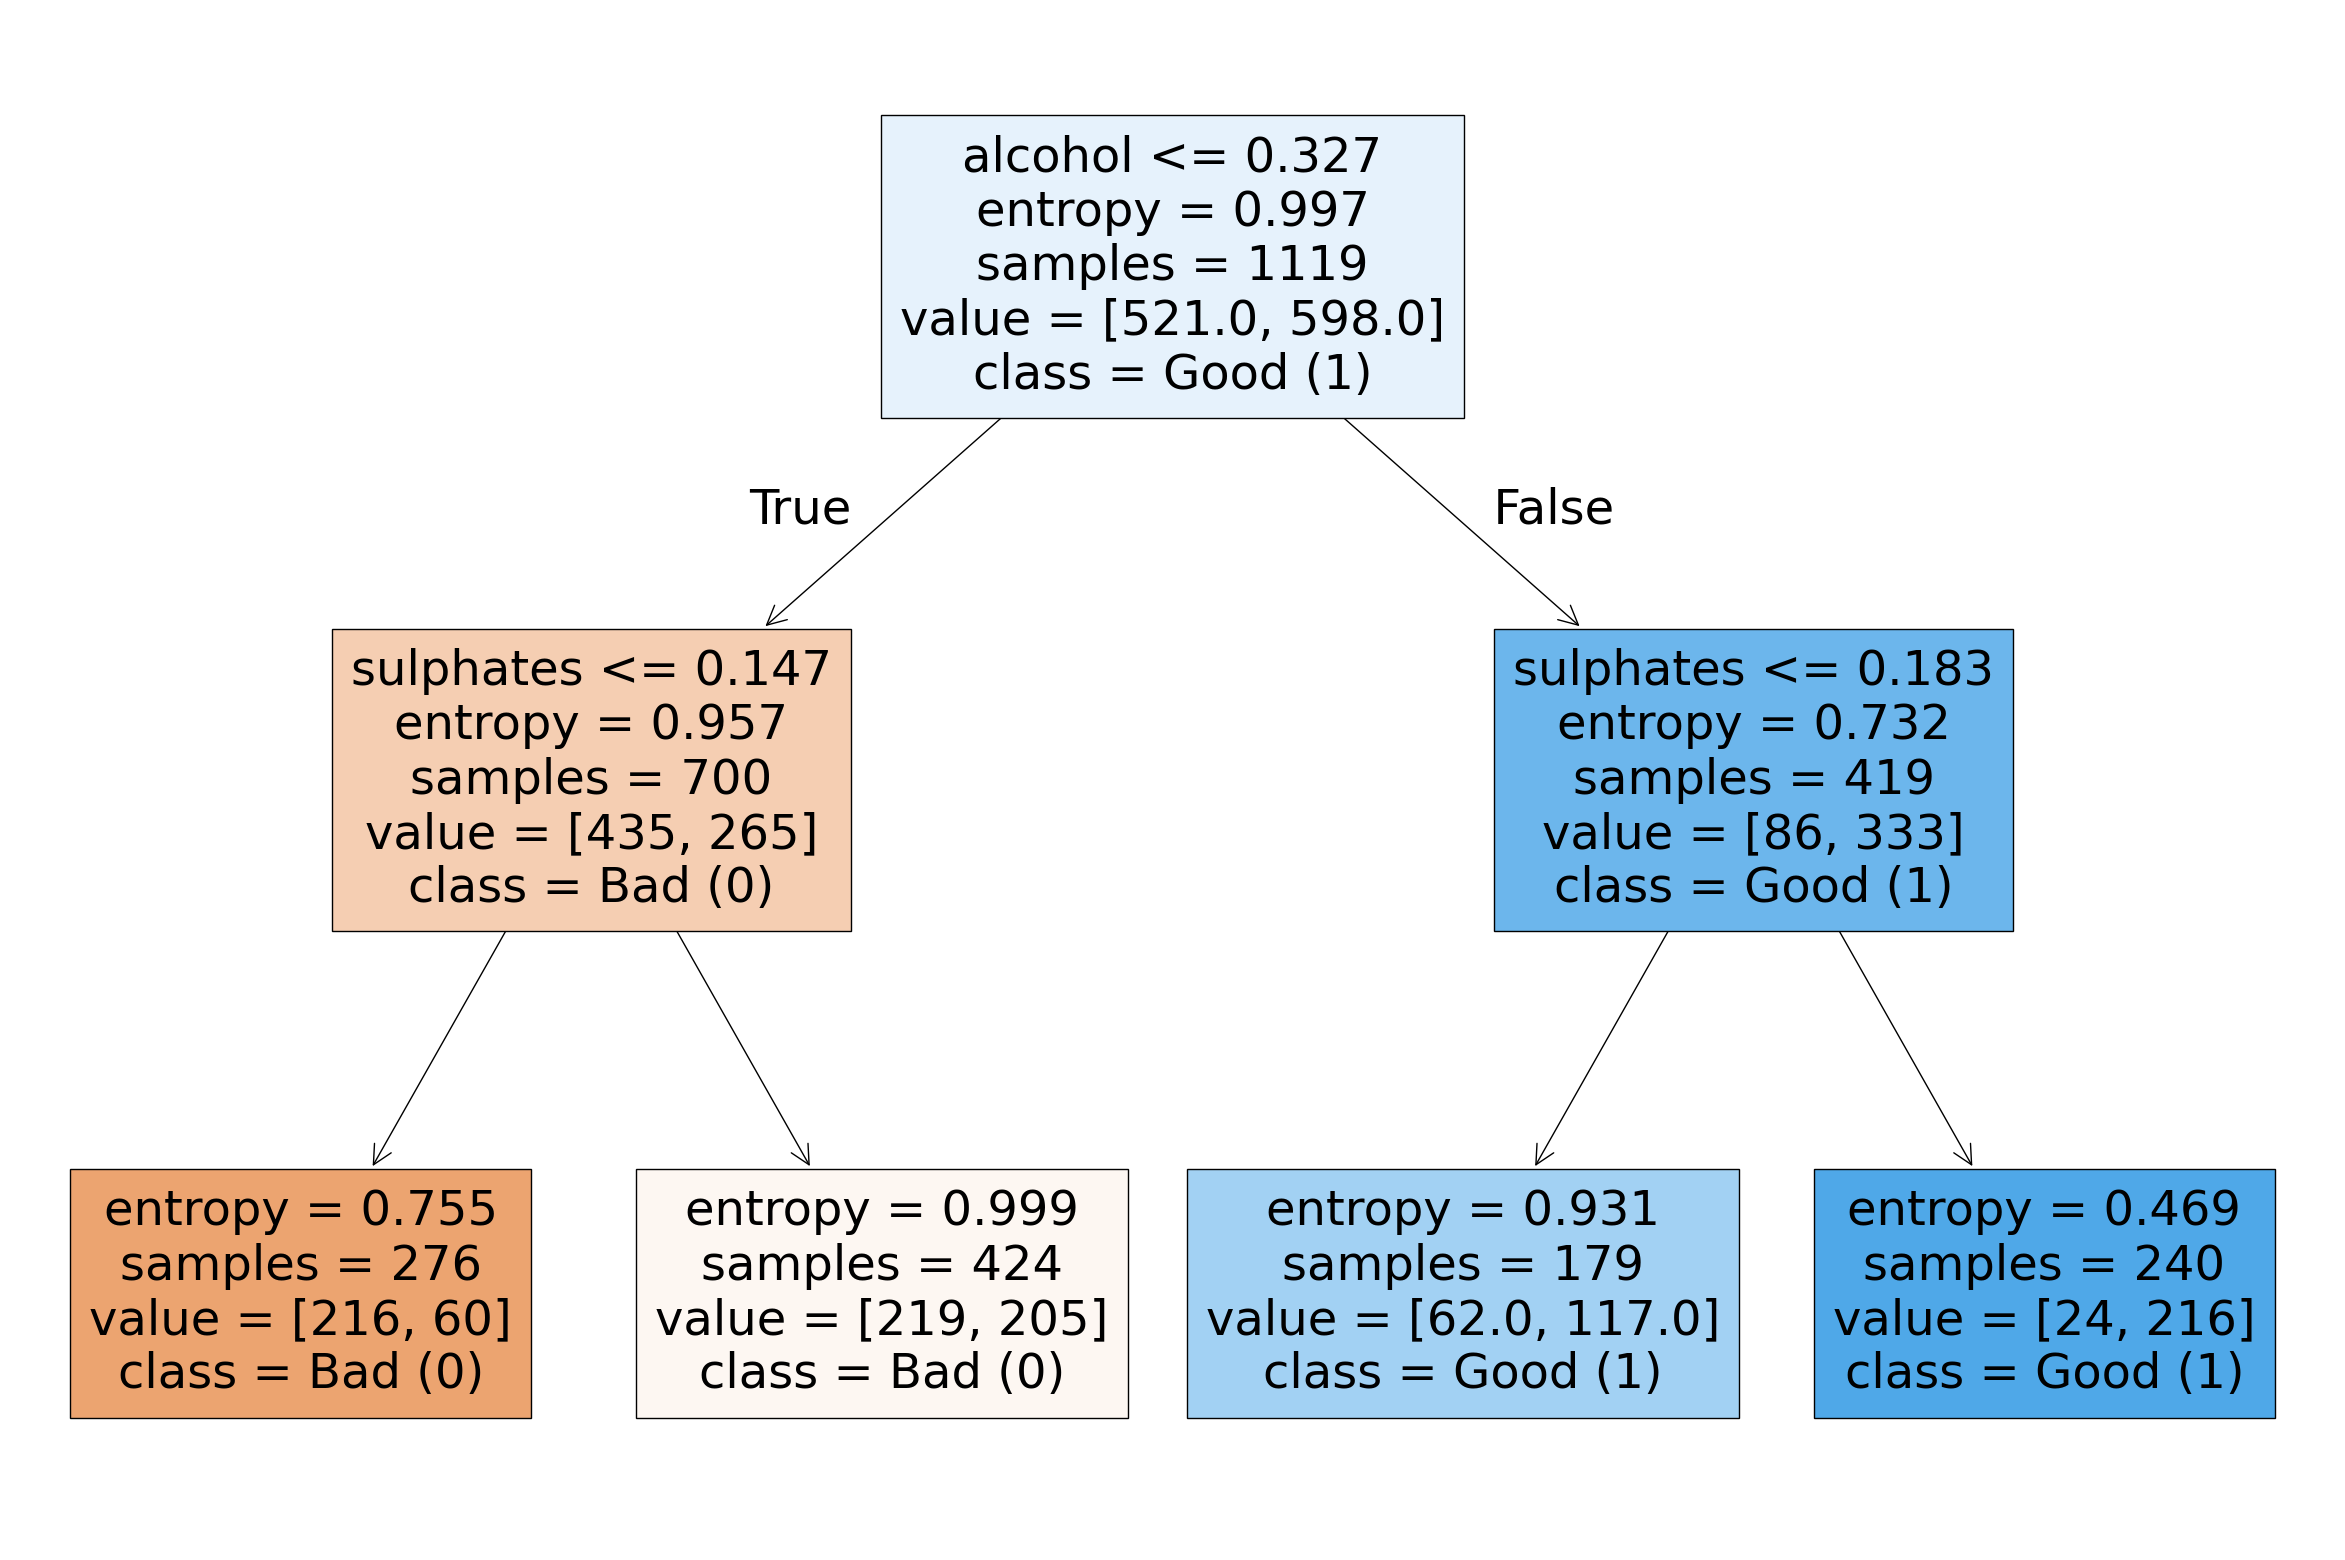

In [ ]:
# Plot the tree
fig = plt.figure(figsize=(30,20))
tree.plot_tree(model_tree,
               feature_names=predictors_train.columns,
               class_names=['Bad (0)','Good (1)'],
               filled=True)

In [ ]:
# Make predictions on training and testing data
prediction_on_train = model_tree.predict(predictors_train)
prediction_on_test = model_tree.predict(predictors_test)

In [ ]:
# Examine the evaluation results on training data: accuracy, precision, recall, and f1-score
print(classification_report(target_train, prediction_on_train))

              precision    recall  f1-score   support

           0       0.62      0.83      0.71       521
           1       0.79      0.56      0.65       598

    accuracy                           0.69      1119
   macro avg       0.71      0.70      0.68      1119
weighted avg       0.71      0.69      0.68      1119



In [ ]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

           0       0.64      0.81      0.72       223
           1       0.79      0.60      0.68       257

    accuracy                           0.70       480
   macro avg       0.71      0.71      0.70       480
weighted avg       0.72      0.70      0.70       480



Decision Tree Classifier achieved an accuracy of 70% on both training and testing data demonstrating good generalization. The tree structure showed that higher alcohol and sulphates were predicted as good. In the classification report there was more bias towards identifying bad wines (recall: 81%), howevever, the f1-score shows balanced performance.

###How do the results compare to those obtained from the regression models? Based on your findings, which approach do you prefer?

Even after converting the data into binary class the SVC model achieved highest accuracy compared to the regression models (multiple linear regression, r-squared=0.37). But in terms of what approach I think is best for understanding which chemical attributes influence wine quality I believe the regression models were most effective in that aspect. Classification models would be more useful for identifying whether a wine is good or bad which would be more useful for distributors and producers.

In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/IS470Homework/SLR,MLR,DT,SVR,MLP.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/IS470Homework/SantiagoDoradoStephanie.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 11 image(s).
[NbConvertApp] Writing 1615730 bytes to /content/drive/MyDrive/Colab Notebooks/IS470Homework/SantiagoDoradoStephanie.html
